#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

#### Importing Datasets

In [2]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled
%store -r Set1_y_Train
%store -r Set1_y_Test
%store -r Set1_X_Train_scaled_2
%store -r Set1_X_Test_scaled_2

#### KNN Regression (All Columns)

In [3]:
knn_regressor = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 10, 25, 50, 100, 500],  
    'weights': ['uniform', 'distance'] 
}

grid_search = GridSearchCV(estimator=knn_regressor, param_grid=param_grid, cv=5, verbose=2, scoring='neg_mean_squared_error')

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

grid_search.fit(Set1_X_Train_scaled, Set1_y_Train_array)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

neg_mse = grid_search.best_score_
print("Negative Mean Squared Error:", neg_mse)

best_knn_regressor = grid_search.best_estimator_

knn_pred_train = best_knn_regressor.predict(Set1_X_Train_scaled)
knn_pred_test = best_knn_regressor.predict(Set1_X_Test_scaled)

knn_pred_train_int = knn_pred_train.astype(int)
knn_pred_test_int = knn_pred_test.astype(int)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.1s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.1s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.1s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.1s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.1s
[CV] END ....................n_neighbors=10, weights=uniform; total time=   0.1s
[CV] END ....................n_neighbors=10, wei

#### KNN Evaluation

In [4]:
# Mean Squared Error
mse_train_knn = mean_squared_error(Set1_y_Train_array, knn_pred_train_int)
mse_test_knn = mean_squared_error(Set1_y_Test_array, knn_pred_test_int)

# Root Mean Squared Error
rmse_train_knn = np.sqrt(mse_train_knn)
rmse_test_knn = np.sqrt(mse_test_knn)

# Mean Absolute Error
mae_train_knn = mean_absolute_error(Set1_y_Train_array, knn_pred_train_int)
mae_test_knn = mean_absolute_error(Set1_y_Test_array, knn_pred_test_int)

# R2 Score
r2_train_knn = r2_score(Set1_y_Train_array, knn_pred_train_int)
r2_test_knn = r2_score(Set1_y_Test_array, knn_pred_test_int)

# Coefficient of Determination
cod_train_knn = explained_variance_score(Set1_y_Train_array, knn_pred_train_int)
cod_test_knn = explained_variance_score(Set1_y_Test_array, knn_pred_test_int)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_knn)
print("Root Mean Squared Error:", rmse_train_knn)
print("Mean Absolute Error:", mae_train_knn)
print("R-squared Score:", r2_train_knn)
print("Coefficient of Determination:", cod_train_knn)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_knn)
print("Root Mean Squared Error:", rmse_test_knn)
print("Mean Absolute Error:", mae_test_knn)
print("R-squared Score:", r2_test_knn)
print("Coefficient of Determination:", cod_test_knn)

--Training Set Evaluation--
Mean Squared Error: 0.13416703019727594
Root Mean Squared Error: 0.3662881791667265
Mean Absolute Error: 0.13416703019727594
R-squared Score: 0.9999717207364925
Coefficient of Determination: 0.9999755148812934

--Testing Set Evaluation--
Mean Squared Error: 1211.36
Root Mean Squared Error: 34.80459739747035
Mean Absolute Error: 27.68
R-squared Score: 0.2985225983479006
Coefficient of Determination: 0.3302331571532673


#### Plot Evaluation Results

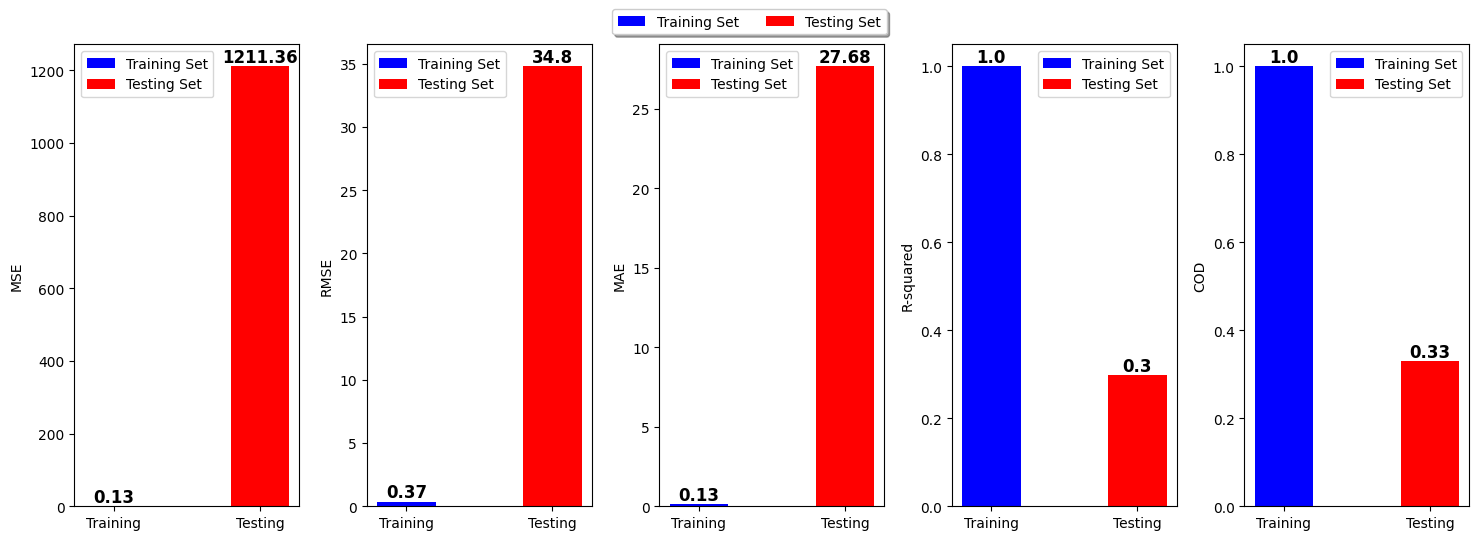

In [5]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_knn, rmse_train_knn, mae_train_knn, r2_train_knn, cod_train_knn]
test_metrics = [mse_test_knn, rmse_test_knn, mae_test_knn, r2_test_knn, cod_test_knn]

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Actual vs Predicted Values

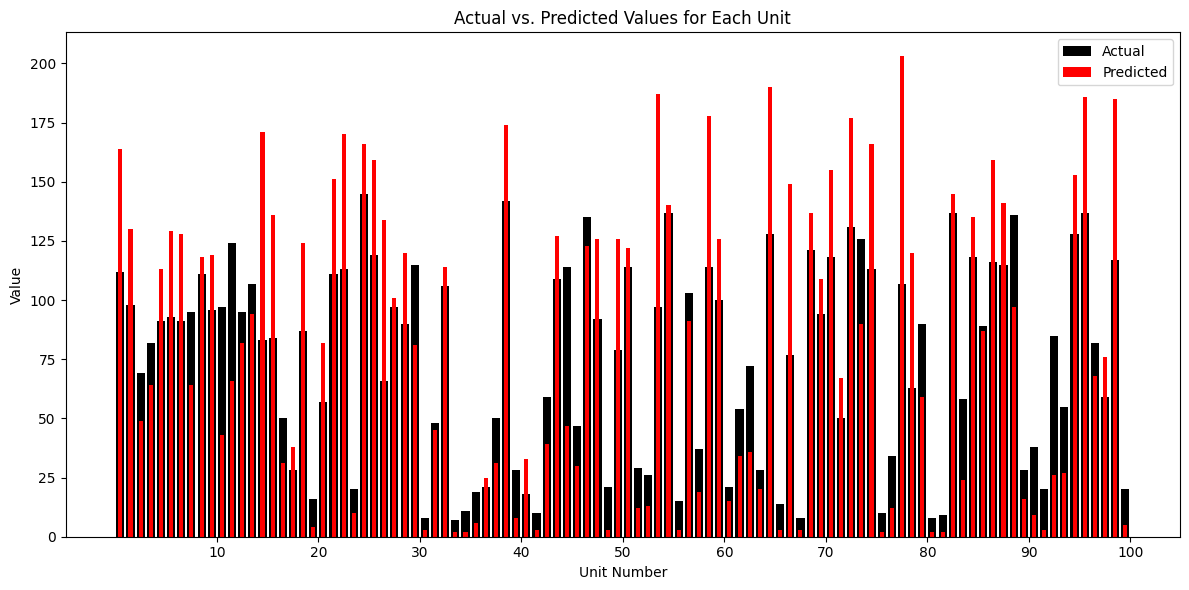

In [6]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(knn_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

#### KNN (Dropped Constant Values)

In [7]:
knn_regressor_2 = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 10, 25, 50, 100, 500],  
    'weights': ['uniform', 'distance'] 
}

grid_search_2 = GridSearchCV(estimator=knn_regressor_2, param_grid=param_grid, cv=5, verbose=2, scoring='neg_mean_squared_error')

Set1_y_Train_array_2 = Set1_y_Train.values.ravel()
Set1_y_Test_array_2 = Set1_y_Test.values.ravel()

grid_search_2.fit(Set1_X_Train_scaled_2, Set1_y_Train_array_2)

best_params_2 = grid_search_2.best_params_
print("Best Parameters:", best_params_2)

neg_mse_2 = grid_search_2.best_score_
print("Negative Mean Squared Error:", neg_mse_2)

best_knn_regressor_2 = grid_search_2.best_estimator_

knn_pred_train_2 = best_knn_regressor_2.predict(Set1_X_Train_scaled_2)
knn_pred_test_2 = best_knn_regressor_2.predict(Set1_X_Test_scaled_2)

knn_pred_train_int_2 = knn_pred_train_2.astype(int)
knn_pred_test_int_2 = knn_pred_test_2.astype(int)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.5s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.5s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.5s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.6s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.6s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.5s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.5s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.5s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.5s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.5s
[CV] END ....................n_neighbors=10, weights=uniform; total time=   0.6s
[CV] END ....................n_neighbors=10, wei

#### KNN Evaluation

In [8]:
# Mean Squared Error
mse_train_knn_2 = mean_squared_error(Set1_y_Train_array_2, knn_pred_train_int_2)
mse_test_knn_2 = mean_squared_error(Set1_y_Test_array_2, knn_pred_test_int_2)

# Root Mean Squared Error
rmse_train_knn_2 = np.sqrt(mse_train_knn_2)
rmse_test_knn_2 = np.sqrt(mse_test_knn_2)

# Mean Absolute Error
mae_train_knn_2 = mean_absolute_error(Set1_y_Train_array_2, knn_pred_train_int_2)
mae_test_knn_2 = mean_absolute_error(Set1_y_Test_array_2, knn_pred_test_int_2)

# R2 Score
r2_train_knn_2 = r2_score(Set1_y_Train_array_2, knn_pred_train_int_2)
r2_test_knn_2 = r2_score(Set1_y_Test_array_2, knn_pred_test_int_2)

# Coefficient of Determination
cod_train_knn_2 = explained_variance_score(Set1_y_Train_array_2, knn_pred_train_int_2)
cod_test_knn_2 = explained_variance_score(Set1_y_Test_array_2, knn_pred_test_int_2)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_knn_2)
print("Root Mean Squared Error:", rmse_train_knn_2)
print("Mean Absolute Error:", mae_train_knn_2)
print("R-squared Score:", r2_train_knn_2)
print("Coefficient of Determination:", cod_train_knn_2)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_knn_2)
print("Root Mean Squared Error:", rmse_test_knn_2)
print("Mean Absolute Error:", mae_test_knn_2)
print("R-squared Score:", r2_test_knn_2)
print("Coefficient of Determination:", cod_test_knn_2)

--Training Set Evaluation--
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0
Mean Absolute Error: 0.0
R-squared Score: 1.0
Coefficient of Determination: 1.0

--Testing Set Evaluation--
Mean Squared Error: 1231.42
Root Mean Squared Error: 35.091594435135036
Mean Absolute Error: 27.84
R-squared Score: 0.2869062029929763
Coefficient of Determination: 0.32000285371865944


#### Plot Evaluation Results

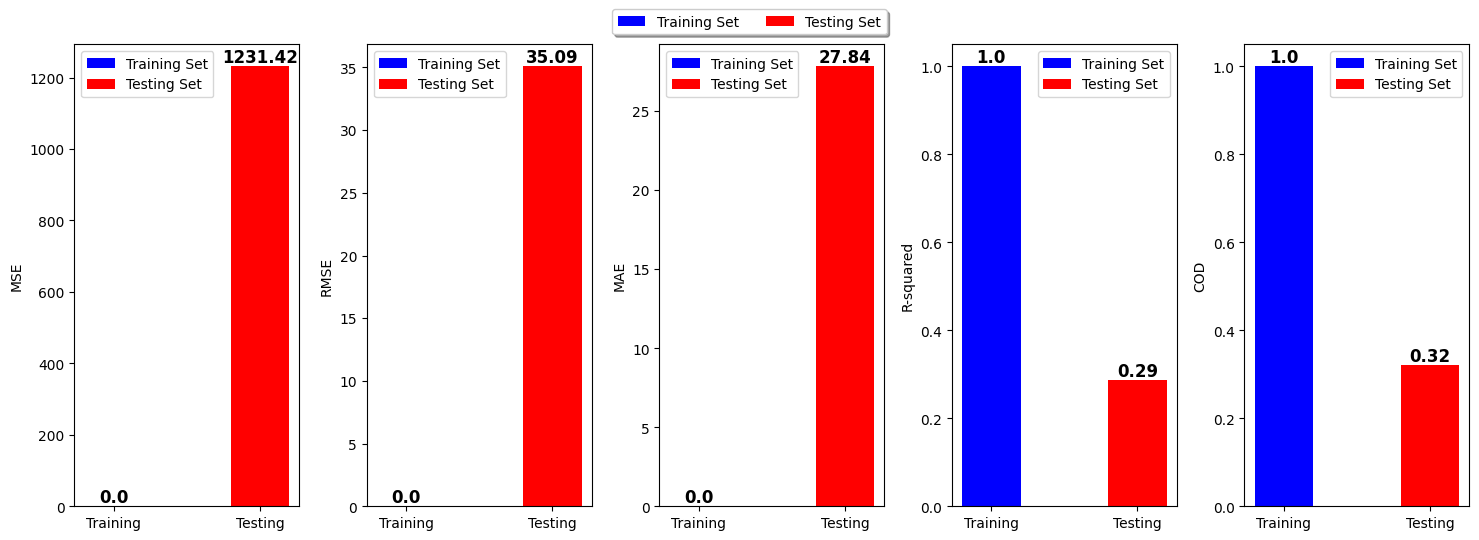

In [9]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics_2 = [mse_train_knn_2, rmse_train_knn_2, mae_train_knn_2, r2_train_knn_2, cod_train_knn_2]
test_metrics_2 = [mse_test_knn_2, rmse_test_knn_2, mae_test_knn_2, r2_test_knn_2, cod_test_knn_2]

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics_2, test_metrics_2)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

#### Plot Actual vs Predicted Values

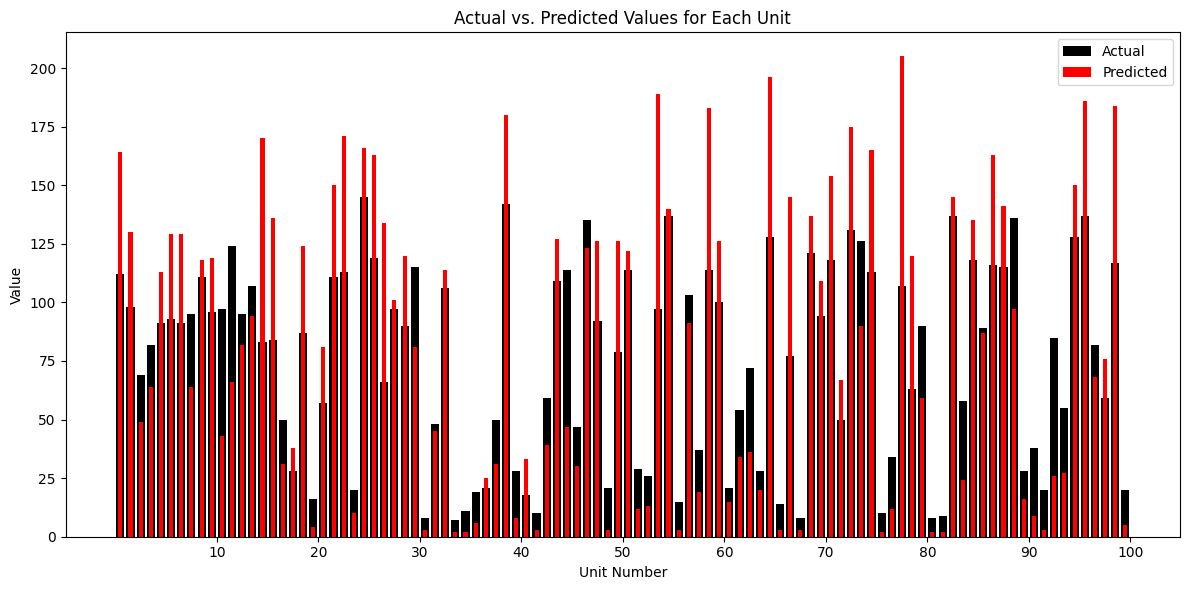

In [10]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(knn_pred_test_int_2)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()